In [ ]:
# ============================================================
# 1. Imports
# ============================================================

import os
import json
import itertools
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

In [ ]:
# ============================================================
# 2. Settings
# ============================================================

TASK = "Prognosis"
LABEL_COL = "Prognosis_label"
IMAGE_TYPE = "whole_image"

model_root = "/host/d/projects/Habitats/models"
whole_image_model_root = os.path.join(model_root, TASK, IMAGE_TYPE)

# Results are saved directly here. No extra subfolder is created.
final_selection_out_dir = os.path.join(whole_image_model_root, "final_selections")
os.makedirs(final_selection_out_dir, exist_ok=True)

# ------------------------------------------------------------
# Manually define selected CV experiments here.
# This works for 1 experiment, 2 experiments, 10 experiments, etc.
#
# Required keys:
#   classifier: folder name under whole_image, e.g. SVM, KNN, XGBoost, RandomForest, LR
#   experiment: experiment folder name, e.g. random20_rfe_top17
#
# Optional keys:
#   name: short display name. If omitted, classifier + experiment is used.
#   probability_col: probability column in cv_predictions.xlsx. If omitted, auto-detects pred_prob.
# ------------------------------------------------------------
selected_cv_experiments = [
    {"classifier": "SVM", "experiment": "random20_rfe_top17"},
    # {"classifier": "KNN", "experiment": "random40_sfs_top12"},
    # {"classifier": "XGBoost", "experiment": "random0_rfe_top7"},
]

print("Whole-image model root:", whole_image_model_root)
print("Final selection output dir:", final_selection_out_dir)
print("Number of selected CV experiments:", len(selected_cv_experiments))
selected_cv_experiments

In [16]:
# ============================================================
# 3. Helper functions
# ============================================================

ID_COLS = ["Patient_set", "Patient_index"]
OPTIONAL_CONTEXT_COLS = ["Image_filepath", "Mask_filepath", "split"]


def make_experiment_tag(item):
    """Create a column-safe tag for one selected experiment."""
    if item.get("name"):
        raw = str(item["name"])
    else:
        raw = f"{item['classifier']}_{item['experiment']}"
    tag = raw.replace(" ", "_").replace("/", "_").replace("-", "_")
    return tag


def find_probability_column(df, explicit_col=None):
    """Find the probability column in cv_predictions.xlsx."""
    if explicit_col is not None:
        if explicit_col not in df.columns:
            raise KeyError(f"Requested probability_col={explicit_col} not found. Columns are: {list(df.columns)}")
        return explicit_col

    preferred = ["pred_prob", "prob", "probability", "y_prob", "oof_prob"]
    for col in preferred:
        if col in df.columns:
            return col

    candidates = [
        col for col in df.columns
        if "prob" in col.lower() and pd.api.types.is_numeric_dtype(df[col])
    ]
    if len(candidates) == 1:
        return candidates[0]
    if len(candidates) > 1:
        raise RuntimeError(f"Multiple probability-like columns found: {candidates}. Please set probability_col manually.")
    raise RuntimeError(f"No probability column found. Columns are: {list(df.columns)}")


def read_cv_prediction(item):
    """Read and standardize one experiment's cv_predictions.xlsx."""
    classifier = item["classifier"]
    experiment = item["experiment"]
    tag = make_experiment_tag(item)

    cv_path = os.path.join(
        whole_image_model_root,
        classifier,
        experiment,
        "cv_predictions.xlsx",
    )
    if not os.path.isfile(cv_path):
        raise FileNotFoundError(f"cv_predictions.xlsx not found: {cv_path}")

    df = pd.read_excel(cv_path)
    prob_col = find_probability_column(df, item.get("probability_col"))

    required = ID_COLS + [LABEL_COL]
    for col in required:
        if col not in df.columns:
            raise KeyError(f"Required column {col} not found in {cv_path}")

    keep_cols = ID_COLS + [LABEL_COL]
    for col in OPTIONAL_CONTEXT_COLS:
        if col in df.columns and col not in keep_cols:
            keep_cols.append(col)
    if "fold" in df.columns:
        keep_cols.append("fold")
    keep_cols.append(prob_col)

    out = df[keep_cols].copy()
    rename_map = {
        prob_col: f"prob_{tag}",
    }
    if "fold" in out.columns:
        rename_map["fold"] = f"fold_{tag}"
    out = out.rename(columns=rename_map)

    out[f"source_path_{tag}"] = cv_path

    if out.duplicated(ID_COLS).any():
        dup = out.loc[out.duplicated(ID_COLS, keep=False), ID_COLS]
        raise RuntimeError(f"Duplicated patient rows found in {cv_path}:\n{dup.head()}")

    info = {
        "tag": tag,
        "classifier": classifier,
        "experiment": experiment,
        "cv_predictions_path": cv_path,
        "probability_column": prob_col,
        "saved_probability_column": f"prob_{tag}",
        "saved_fold_column": f"fold_{tag}" if f"fold_{tag}" in out.columns else "",
        "n_rows": int(out.shape[0]),
    }
    return out, info


def merge_prediction_tables(prediction_tables):
    """Inner-merge selected experiment predictions by patient identity and label."""
    if len(prediction_tables) == 0:
        raise ValueError("No prediction tables were provided.")

    merged = prediction_tables[0].copy()
    for next_df in prediction_tables[1:]:
        # Keep only non-duplicated context columns from later experiments.
        duplicate_context = [
            col for col in OPTIONAL_CONTEXT_COLS
            if col in next_df.columns and col in merged.columns
        ]
        next_df2 = next_df.drop(columns=duplicate_context)
        merged = merged.merge(next_df2, on=ID_COLS + [LABEL_COL], how="inner", validate="one_to_one")

    return merged


def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, y_score))


def bootstrap_auc_ci(y_true, y_score, n_bootstrap=2000, ci=0.95, random_state=0):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return np.nan, np.nan

    rng = np.random.default_rng(random_state)
    aucs = []
    n = len(y_true)
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_score[idx]))

    if len(aucs) == 0:
        return np.nan, np.nan
    alpha = (1 - ci) / 2
    return float(np.quantile(aucs, alpha)), float(np.quantile(aucs, 1 - alpha))


def best_threshold_by_youden(y_true, y_score):
    """Pick threshold by maximizing sensitivity + specificity - 1."""
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    specificity = 1 - fpr
    youden = tpr + specificity - 1
    best_i = int(np.argmax(youden))
    return float(thresholds[best_i])


def binary_metrics_at_threshold(y_true, y_score, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    accuracy = (tp + tn) / max(tp + tn + fp + fn, 1)
    sensitivity = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)
    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def evaluate_probability(y_true, y_score, name, random_state=0):
    auc = safe_auc(y_true, y_score)
    ci_low, ci_high = bootstrap_auc_ci(y_true, y_score, random_state=random_state)
    threshold = best_threshold_by_youden(y_true, y_score)
    metrics = binary_metrics_at_threshold(y_true, y_score, threshold)
    metrics.update({
        "method": name,
        "auc": auc,
        "auc_ci_low": ci_low,
        "auc_ci_high": ci_high,
        "n_cases": int(len(y_true)),
        "positive_count": int(np.sum(np.asarray(y_true).astype(int) == 1)),
        "negative_count": int(np.sum(np.asarray(y_true).astype(int) == 0)),
    })
    return metrics

In [5]:
# ============================================================
# 4. Read and merge selected CV predictions
# ============================================================

if len(selected_cv_experiments) == 0:
    raise ValueError("selected_cv_experiments is empty. Please define at least one experiment.")

prediction_tables = []
experiment_info = []

for item in selected_cv_experiments:
    df_one, info_one = read_cv_prediction(item)
    prediction_tables.append(df_one)
    experiment_info.append(info_one)
    print("Loaded:", info_one["tag"], "rows:", info_one["n_rows"])
    print("  path:", info_one["cv_predictions_path"])

merged_df = merge_prediction_tables(prediction_tables)

prob_cols = [info["saved_probability_column"] for info in experiment_info]
fold_cols = [info["saved_fold_column"] for info in experiment_info if info["saved_fold_column"]]

print("\nMerged prediction table shape:", merged_df.shape)
print("Probability columns:", prob_cols)
print("Fold columns:", fold_cols)
print("Number of cases present in every selected experiment:", merged_df.shape[0])

# Basic label consistency is guaranteed by merging on LABEL_COL.
print("Label counts:")
display(merged_df[LABEL_COL].value_counts().sort_index())

merged_df.head()

Loaded: SVM_random20_rfe_top15 rows: 232
  path: /host/d/projects/Habitats/models/Prognosis/whole_image/SVM/random20_rfe_top15/cv_predictions.xlsx
Loaded: SVM_random20_rfe_top30 rows: 232
  path: /host/d/projects/Habitats/models/Prognosis/whole_image/SVM/random20_rfe_top30/cv_predictions.xlsx

Merged prediction table shape: (232, 12)
Probability columns: ['prob_SVM_random20_rfe_top15', 'prob_SVM_random20_rfe_top30']
Fold columns: ['fold_SVM_random20_rfe_top15', 'fold_SVM_random20_rfe_top30']
Number of cases present in every selected experiment: 232
Label counts:


0    163
1     69
Name: Prognosis_label, dtype: int64

,Patient_set,Patient_index,Prognosis_label,Image_filepath,Mask_filepath,split,fold_SVM_random20_rfe_top15,prob_SVM_random20_rfe_top15,source_path_SVM_random20_rfe_top15,fold_SVM_random20_rfe_top30,prob_SVM_random20_rfe_top30,source_path_SVM_random20_rfe_top30
0,set_1,38,1,/host/e/D/Data/Habitats/Jishuitan/original_dat...,/host/e/D/Data/Habitats/Jishuitan/original_dat...,train,0,0.591917,/host/d/projects/Habitats/models/Prognosis/who...,0,0.500000,/host/d/projects/Habitats/models/Prognosis/who...
1,set_1,41,1,/host/e/D/Data/Habitats/Jishuitan/original_dat...,/host/e/D/Data/Habitats/Jishuitan/original_dat...,train,0,0.361004,/host/d/projects/Habitats/models/Prognosis/who...,0,0.359462,/host/d/projects/Habitats/models/Prognosis/who...
2,set_1,52,0,/host/e/D/Data/Habitats/Jishuitan/original_dat...,/host/e/D/Data/Habitats/Jishuitan/original_dat...,train,0,0.000231,/host/d/projects/Habitats/models/Prognosis/who...,0,0.009421,/host/d/projects/Habitats/models/Prognosis/who...
3,set_1,93,0,/host/e/D/Data/Habitats/Jishuitan/original_dat...,/host/e/D/Data/Habitats/Jishuitan/original_dat...,train,0,0.219470,/host/d/projects/Habitats/models/Prognosis/who...,0,0.196881,/host/d/projects/Habitats/models/Prognosis/who...
4,set_1,95,0,/host/e/D/Data/Habitats/Jishuitan/original_dat...,/host/e/D/Data/Habitats/Jishuitan/original_dat...,train,0,0.170035,/host/d/projects/Habitats/models/Prognosis/who...,0,0.428518,/host/d/projects/Habitats/models/Prognosis/who...


In [ ]:
# ============================================================
# 5. CV mean fusion, best fold-wise mix fusion, and metrics
# ============================================================

# Use the first selected experiment's fold assignment as the reference fold.
# This is intentionally simple and user-controlled. If later experiments use a different
# random_state/fold split, no special remapping is performed.
reference_fold_col = experiment_info[0]["saved_fold_column"]
if not reference_fold_col or reference_fold_col not in merged_df.columns:
    raise RuntimeError("The first selected CV experiment does not have a fold column in cv_predictions.xlsx.")

merged_df["fold"] = merged_df[reference_fold_col].astype(int)
reference_folds = sorted(merged_df["fold"].dropna().astype(int).unique().tolist())
selected_tags = [info["tag"] for info in experiment_info]

print("Selected experiments used in this run:")
for i, tag in enumerate(selected_tags):
    print(f"  {i}: {tag}")
print("Reference fold column:", reference_fold_col)
print("Reference folds:", reference_folds)

if reference_folds != [0, 1, 2, 3, 4]:
    print("Warning: expected folds [0,1,2,3,4], but found:", reference_folds)

# Works for 1 selected experiment too: mean of one column equals that experiment probability.
merged_df["prob_mean"] = merged_df[prob_cols].astype(float).mean(axis=1)

y_true = merged_df[LABEL_COL].astype(int).to_numpy()

# Make sure probabilities are numeric and complete before searching.
for col in prob_cols:
    merged_df[col] = pd.to_numeric(merged_df[col], errors="coerce")
if merged_df[prob_cols].isna().any().any():
    bad_cols = merged_df[prob_cols].columns[merged_df[prob_cols].isna().any()].tolist()
    raise RuntimeError(f"NaN probabilities found in columns: {bad_cols}")

# ------------------------------------------------------------
# Best fold-wise mix search
# ------------------------------------------------------------
# For n experiments and 5 folds, there are n^5 combinations.
# For each fold, choose one experiment's probability column.
# Only the best mix is kept and saved; non-best combinations are not recorded.


def search_best_fold_mix(allowed_experiment_indices):
    """Search best fold-wise mix over a subset of experiment indices."""
    allowed_experiment_indices = list(allowed_experiment_indices)
    best_auc = -np.inf
    best_combo = None
    best_prob = None
    combo_count_local = 0

    for combo in itertools.product(allowed_experiment_indices, repeat=len(reference_folds)):
        combo_count_local += 1
        candidate_prob = np.zeros(merged_df.shape[0], dtype=float)

        for fold_value, experiment_idx in zip(reference_folds, combo):
            fold_mask = merged_df["fold"].to_numpy() == fold_value
            candidate_prob[fold_mask] = merged_df.loc[fold_mask, prob_cols[experiment_idx]].astype(float).to_numpy()

        candidate_auc = safe_auc(y_true, candidate_prob)
        if candidate_auc > best_auc:
            best_auc = candidate_auc
            best_combo = combo
            best_prob = candidate_prob.copy()

    if best_prob is None:
        raise RuntimeError("Could not create best mix probability.")

    return best_auc, best_combo, best_prob, combo_count_local


best_mix_auc, best_mix_combo, best_mix_prob, combo_count = search_best_fold_mix(range(len(prob_cols)))

# Sanity check for the exact concern: if more experiments are added, the best full search
# should be at least as good as the search restricted to the first two experiments.
# If this fails, something is wrong with alignment or state.
first_two_mix_auc = np.nan
first_two_mix_combo = None
if len(prob_cols) > 2:
    first_two_mix_auc, first_two_mix_combo, _, first_two_combo_count = search_best_fold_mix([0, 1])
    print("First-two-only mix AUC sanity lower bound:", first_two_mix_auc)
    print("First-two-only mix combo:", first_two_mix_combo)
    if best_mix_auc + 1e-12 < first_two_mix_auc:
        raise RuntimeError(
            "Best mix over all selected experiments is lower than the mix restricted to the first two experiments. "
            "This should be impossible. Restart the kernel and rerun all cells; if it persists, inspect patient alignment."
        )

merged_df["prob_mix"] = best_mix_prob

mix_selection_rows = []
for fold_value, experiment_idx in zip(reference_folds, best_mix_combo):
    mix_selection_rows.append({
        "fold": int(fold_value),
        "selected_experiment_index": int(experiment_idx),
        "selected_experiment_tag": experiment_info[experiment_idx]["tag"],
        "selected_probability_column": prob_cols[experiment_idx],
        "classifier": experiment_info[experiment_idx]["classifier"],
        "experiment": experiment_info[experiment_idx]["experiment"],
    })

mix_selection_df = pd.DataFrame(mix_selection_rows)

print("Searched mix combinations:", combo_count)
print("Best mix AUC:", best_mix_auc)
print("Best mix combo:", best_mix_combo)
display(mix_selection_df)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
metrics_rows = []

# Optional: record each individual experiment's metrics in the same table.
for info in experiment_info:
    col = info["saved_probability_column"]
    row = evaluate_probability(
        y_true=y_true,
        y_score=merged_df[col].to_numpy(),
        name=info["tag"],
        random_state=0,
    )
    row.update({
        "fusion_type": "single_experiment",
        "n_selected_experiments": 1,
        "selected_experiments": info["tag"],
    })
    metrics_rows.append(row)

# Mean fusion.
mean_row = evaluate_probability(
    y_true=y_true,
    y_score=merged_df["prob_mean"].to_numpy(),
    name="mean",
    random_state=0,
)
mean_row.update({
    "fusion_type": "mean_probability",
    "n_selected_experiments": len(prob_cols),
    "selected_experiments": "; ".join(selected_tags),
})
metrics_rows.append(mean_row)

# Best mix fusion.
mix_row = evaluate_probability(
    y_true=y_true,
    y_score=merged_df["prob_mix"].to_numpy(),
    name="mix",
    random_state=0,
)
mix_row.update({
    "fusion_type": "best_fold_wise_mix",
    "n_selected_experiments": len(prob_cols),
    "selected_experiments": "; ".join(selected_tags),
    "first_two_only_mix_auc_lower_bound": first_two_mix_auc,
})
metrics_rows.append(mix_row)

metrics_df = pd.DataFrame(metrics_rows)

metric_col_order = [
    "method",
    "fusion_type",
    "n_selected_experiments",
    "selected_experiments",
    "first_two_only_mix_auc_lower_bound",
    "n_cases",
    "positive_count",
    "negative_count",
    "auc",
    "auc_ci_low",
    "auc_ci_high",
    "threshold",
    "accuracy",
    "sensitivity",
    "specificity",
    "tn",
    "fp",
    "fn",
    "tp",
]
metrics_df = metrics_df[[col for col in metric_col_order if col in metrics_df.columns]]

print("Mean fusion AUC:", mean_row["auc"])
print("Mean fusion AUC 95% CI:", mean_row["auc_ci_low"], "-", mean_row["auc_ci_high"])
print("Mix fusion AUC:", mix_row["auc"])
print("Mix fusion AUC 95% CI:", mix_row["auc_ci_low"], "-", mix_row["auc_ci_high"])

display(metrics_df)

In [ ]:
# ============================================================
# 6. Save CV prediction table, metrics, best-mix selection, and manifest
# ============================================================

prediction_save_path = os.path.join(final_selection_out_dir, "cv_final_selection_predictions.xlsx")
metrics_save_path = os.path.join(final_selection_out_dir, "cv_final_selection_metrics.xlsx")
mix_selection_save_path = os.path.join(final_selection_out_dir, "cv_final_selection_best_mix.xlsx")
manifest_save_path = os.path.join(final_selection_out_dir, "cv_final_selection_manifest.json")

# Put core columns first.
core_cols = ID_COLS + [LABEL_COL]
for col in OPTIONAL_CONTEXT_COLS:
    if col in merged_df.columns and col not in core_cols:
        core_cols.append(col)

ordered_cols = core_cols + ["fold"] + fold_cols + prob_cols + ["prob_mean", "prob_mix"]
remaining_cols = [col for col in merged_df.columns if col not in ordered_cols]
merged_save_df = merged_df[ordered_cols + remaining_cols].copy()

merged_save_df.to_excel(prediction_save_path, index=False)
metrics_df.to_excel(metrics_save_path, index=False)
mix_selection_df.to_excel(mix_selection_save_path, index=False)

manifest = {
    "task": TASK,
    "label_col": LABEL_COL,
    "image_type": IMAGE_TYPE,
    "final_selection_out_dir": final_selection_out_dir,
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "fusion_methods": ["mean_probability", "best_fold_wise_mix"],
    "selected_cv_experiments": selected_cv_experiments,
    "experiment_info": experiment_info,
    "reference_fold_column": reference_fold_col,
    "reference_folds": reference_folds,
    "mix_combinations_searched": int(combo_count),
    "first_two_only_mix_auc_lower_bound": None if pd.isna(first_two_mix_auc) else float(first_two_mix_auc),
    "probability_columns": prob_cols,
    "n_cases_after_inner_merge": int(merged_df.shape[0]),
    "prediction_save_path": prediction_save_path,
    "metrics_save_path": metrics_save_path,
    "mix_selection_save_path": mix_selection_save_path,
}

with open(manifest_save_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

print("Saved CV predictions:", prediction_save_path)
print("Saved CV metrics:", metrics_save_path)
print("Saved best-mix selection:", mix_selection_save_path)
print("Saved CV manifest:", manifest_save_path)

In [ ]:
# ============================================================
# 7. Plot and save CV mean + mix ROC
# ============================================================

roc_save_path = os.path.join(final_selection_out_dir, "ROC_curve_cv_final_selection_mean_mix.pdf")

plt.figure(figsize=(6, 6))

for prob_col, label_name in [
    ("prob_mean", "Mean fusion"),
    ("prob_mix", "Best fold-wise mix"),
]:
    y_score = merged_df[prob_col].astype(float).to_numpy()
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_value = safe_auc(y_true, y_score)
    plt.plot(fpr, tpr, linewidth=2, label=f"{label_name} AUC = {auc_value:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Whole-image CV final selection ROC")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(roc_save_path)
plt.show()

print("Saved CV ROC:", roc_save_path)

# Internal Test Final Selection

This section is independent from the CV/validation section above. Manually choose one or more completed experiments, read each experiment's `test_predictions.xlsx`, use its already-selected `prob_final`, and average those final probabilities.

In [23]:
# ============================================================
# 8. Internal test settings
# ============================================================

# Define selected internal-test experiments independently from selected_cv_experiments.
# This works for 1 experiment, 2 experiments, 10 experiments, etc.
#
# For each experiment, the notebook reads:
#   /host/d/projects/Habitats/models/Prognosis/whole_image/{classifier}/{experiment}/test_predictions.xlsx
#
# It uses prob_final, which was already chosen by the original ML script from
# mean / best / alldata. The selected final method is kept in the output table.
selected_test_experiments = [
    {"classifier": "SVM", "experiment": "random20_rfe_top17"},
    # {"classifier": "KNN", "experiment": "random40_sfs_top12"},
    # {"classifier": "XGBoost", "experiment": "random0_rfe_top7"},
]

print("Number of selected internal-test experiments:", len(selected_test_experiments))
selected_test_experiments

Number of selected internal-test experiments: 1


[{'classifier': 'SVM', 'experiment': 'random20_rfe_top17'}]

In [24]:
# ============================================================
# 9. Internal test helper functions
# ============================================================


def resolve_test_final_probability(df):
    """Return the probability column used as final internal-test probability."""
    if "prob_final" in df.columns:
        return "prob_final"

    if "final_selected_method" not in df.columns:
        raise KeyError("test_predictions.xlsx has neither prob_final nor final_selected_method.")

    methods = df["final_selected_method"].dropna().astype(str).str.lower().unique().tolist()
    if len(methods) != 1:
        raise RuntimeError(f"Cannot infer one final method. Found final_selected_method values: {methods}")

    method = methods[0]
    if method in {"alldata", "all"} and "prob_alldata" in df.columns:
        return "prob_alldata"
    if method == "best" and "prob_best" in df.columns:
        return "prob_best"
    if method == "mean" and "prob_mean" in df.columns:
        return "prob_mean"

    raise RuntimeError(f"Could not map final_selected_method={method} to a probability column.")


def read_test_prediction(item):
    """Read and standardize one experiment's internal-test predictions."""
    classifier = item["classifier"]
    experiment = item["experiment"]
    tag = make_experiment_tag(item)

    test_path = os.path.join(
        whole_image_model_root,
        classifier,
        experiment,
        "test_predictions.xlsx",
    )
    if not os.path.isfile(test_path):
        raise FileNotFoundError(f"test_predictions.xlsx not found: {test_path}")

    df = pd.read_excel(test_path)
    prob_col = resolve_test_final_probability(df)

    required = ID_COLS + [LABEL_COL]
    for col in required:
        if col not in df.columns:
            raise KeyError(f"Required column {col} not found in {test_path}")

    keep_cols = ID_COLS + [LABEL_COL]
    for col in OPTIONAL_CONTEXT_COLS:
        if col in df.columns and col not in keep_cols:
            keep_cols.append(col)
    if "fold" in df.columns:
        keep_cols.append("fold")
    if "final_selected_method" in df.columns:
        keep_cols.append("final_selected_method")
    if "best_model_fold" in df.columns:
        keep_cols.append("best_model_fold")
    keep_cols.append(prob_col)

    out = df[keep_cols].copy()

    rename_map = {
        prob_col: f"prob_final_{tag}",
    }
    if "fold" in out.columns:
        rename_map["fold"] = f"test_fold_{tag}"
    if "final_selected_method" in out.columns:
        rename_map["final_selected_method"] = f"final_selected_method_{tag}"
    if "best_model_fold" in out.columns:
        rename_map["best_model_fold"] = f"best_model_fold_{tag}"
    out = out.rename(columns=rename_map)

    out[f"source_path_{tag}"] = test_path

    if out.duplicated(ID_COLS).any():
        dup = out.loc[out.duplicated(ID_COLS, keep=False), ID_COLS]
        raise RuntimeError(f"Duplicated patient rows found in {test_path}:\n{dup.head()}")

    final_method_col = f"final_selected_method_{tag}"
    if final_method_col in out.columns:
        final_methods = sorted(out[final_method_col].dropna().astype(str).unique().tolist())
    else:
        final_methods = []

    info = {
        "tag": tag,
        "classifier": classifier,
        "experiment": experiment,
        "test_predictions_path": test_path,
        "probability_column": prob_col,
        "saved_probability_column": f"prob_final_{tag}",
        "saved_final_method_column": final_method_col if final_method_col in out.columns else "",
        "final_selected_methods_in_file": final_methods,
        "n_rows": int(out.shape[0]),
    }
    return out, info


def merge_test_prediction_tables(prediction_tables):
    """Inner-merge selected internal-test predictions by patient identity and label."""
    if len(prediction_tables) == 0:
        raise ValueError("No internal-test prediction tables were provided.")

    merged = prediction_tables[0].copy()
    for next_df in prediction_tables[1:]:
        duplicate_context = [
            col for col in OPTIONAL_CONTEXT_COLS
            if col in next_df.columns and col in merged.columns
        ]
        next_df2 = next_df.drop(columns=duplicate_context)
        merged = merged.merge(next_df2, on=ID_COLS + [LABEL_COL], how="inner", validate="one_to_one")

    return merged

In [25]:
# ============================================================
# 10. Read and merge selected internal-test predictions
# ============================================================

if len(selected_test_experiments) == 0:
    raise ValueError("selected_test_experiments is empty. Please define at least one experiment.")

test_prediction_tables = []
test_experiment_info = []

for item in selected_test_experiments:
    df_one, info_one = read_test_prediction(item)
    test_prediction_tables.append(df_one)
    test_experiment_info.append(info_one)
    print("Loaded:", info_one["tag"], "rows:", info_one["n_rows"])
    print("  path:", info_one["test_predictions_path"])
    print("  final selected method(s):", info_one["final_selected_methods_in_file"])

test_merged_df = merge_test_prediction_tables(test_prediction_tables)

test_prob_cols = [info["saved_probability_column"] for info in test_experiment_info]
test_fold_cols = [col for col in test_merged_df.columns if col.startswith("test_fold_")]
test_final_method_cols = [info["saved_final_method_column"] for info in test_experiment_info if info["saved_final_method_column"]]
test_best_fold_cols = [col for col in test_merged_df.columns if col.startswith("best_model_fold_")]

print("\nMerged internal-test prediction table shape:", test_merged_df.shape)
print("Final probability columns:", test_prob_cols)
print("Final method columns:", test_final_method_cols)
print("Number of internal-test cases present in every selected experiment:", test_merged_df.shape[0])

print("Label counts:")
display(test_merged_df[LABEL_COL].value_counts().sort_index())

test_merged_df.head()

Loaded: SVM_random20_rfe_top17 rows: 98
  path: /host/d/projects/Habitats/models/Prognosis/whole_image/SVM/random20_rfe_top17/test_predictions.xlsx
  final selected method(s): ['best']

Merged internal-test prediction table shape: (98, 11)
Final probability columns: ['prob_final_SVM_random20_rfe_top17']
Final method columns: ['final_selected_method_SVM_random20_rfe_top17']
Number of internal-test cases present in every selected experiment: 98
Label counts:


0    69
1    29
Name: Prognosis_label, dtype: int64

,Patient_set,Patient_index,Prognosis_label,Image_filepath,Mask_filepath,split,test_fold_SVM_random20_rfe_top17,final_selected_method_SVM_random20_rfe_top17,best_model_fold_SVM_random20_rfe_top17,prob_final_SVM_random20_rfe_top17,source_path_SVM_random20_rfe_top17
0,set_1,21,1,/host/e/D/Data/Habitats/Jishuitan/original_dat...,/host/e/D/Data/Habitats/Jishuitan/original_dat...,internal test,5,best,3,0.334884,/host/d/projects/Habitats/models/Prognosis/who...
1,set_1,24,0,/host/e/D/Data/Habitats/Jishuitan/original_dat...,/host/e/D/Data/Habitats/Jishuitan/original_dat...,internal test,5,best,3,0.157986,/host/d/projects/Habitats/models/Prognosis/who...
2,set_1,28,0,/host/e/D/Data/Habitats/Jishuitan/original_dat...,/host/e/D/Data/Habitats/Jishuitan/original_dat...,internal test,5,best,3,0.473070,/host/d/projects/Habitats/models/Prognosis/who...
3,set_1,36,0,/host/e/D/Data/Habitats/Jishuitan/original_dat...,/host/e/D/Data/Habitats/Jishuitan/original_dat...,internal test,5,best,3,0.311759,/host/d/projects/Habitats/models/Prognosis/who...
4,set_1,40,0,/host/e/D/Data/Habitats/Jishuitan/original_dat...,/host/e/D/Data/Habitats/Jishuitan/original_dat...,internal test,5,best,3,0.117651,/host/d/projects/Habitats/models/Prognosis/who...


In [26]:
# ============================================================
# 11. Internal test mean probability fusion and metrics
# ============================================================

# Works for 1 selected experiment too: mean of one column equals that experiment's final probability.
test_merged_df["prob_final_mean"] = test_merged_df[test_prob_cols].astype(float).mean(axis=1)

y_test_true = test_merged_df[LABEL_COL].astype(int).to_numpy()

test_metrics_rows = []

# Record each individual experiment's final internal-test metrics.
for info in test_experiment_info:
    col = info["saved_probability_column"]
    row = evaluate_probability(
        y_true=y_test_true,
        y_score=test_merged_df[col].to_numpy(),
        name=info["tag"],
        random_state=0,
    )
    row.update({
        "fusion_type": "single_experiment_final",
        "n_selected_experiments": 1,
        "selected_experiments": info["tag"],
        "source_final_method": "; ".join(info["final_selected_methods_in_file"]),
    })
    test_metrics_rows.append(row)

# Main internal-test mean fusion.
test_mean_row = evaluate_probability(
    y_true=y_test_true,
    y_score=test_merged_df["prob_final_mean"].to_numpy(),
    name="internal_test_mean_final_probability",
    random_state=0,
)
test_mean_row.update({
    "fusion_type": "mean_of_experiment_final_probabilities",
    "n_selected_experiments": len(test_prob_cols),
    "selected_experiments": "; ".join([info["tag"] for info in test_experiment_info]),
    "source_final_method": "; ".join([
        f"{info['tag']}={','.join(info['final_selected_methods_in_file'])}"
        for info in test_experiment_info
    ]),
})
test_metrics_rows.append(test_mean_row)

test_metrics_df = pd.DataFrame(test_metrics_rows)

test_metric_col_order = [
    "method",
    "fusion_type",
    "n_selected_experiments",
    "selected_experiments",
    "source_final_method",
    "n_cases",
    "positive_count",
    "negative_count",
    "auc",
    "auc_ci_low",
    "auc_ci_high",
    "threshold",
    "accuracy",
    "sensitivity",
    "specificity",
    "tn",
    "fp",
    "fn",
    "tp",
]
test_metrics_df = test_metrics_df[[col for col in test_metric_col_order if col in test_metrics_df.columns]]

print("Internal-test mean fusion AUC:", test_mean_row["auc"])
print("Internal-test mean fusion AUC 95% CI:", test_mean_row["auc_ci_low"], "-", test_mean_row["auc_ci_high"])
print("Internal-test mean fusion threshold:", test_mean_row["threshold"])
print("Internal-test mean fusion accuracy/sensitivity/specificity:", test_mean_row["accuracy"], test_mean_row["sensitivity"], test_mean_row["specificity"])

display(test_metrics_df)

Internal-test mean fusion AUC: 0.7756121939030485
Internal-test mean fusion AUC 95% CI: 0.6725323728865568 - 0.8675349825087455
Internal-test mean fusion threshold: 0.2889268176405021
Internal-test mean fusion accuracy/sensitivity/specificity: 0.7346938775510204 0.7931034482758621 0.7101449275362319


,method,fusion_type,n_selected_experiments,selected_experiments,source_final_method,n_cases,positive_count,negative_count,auc,auc_ci_low,auc_ci_high,threshold,accuracy,sensitivity,specificity,tn,fp,fn,tp
0,SVM_random20_rfe_top17,single_experiment_final,1,SVM_random20_rfe_top17,best,98,29,69,0.775612,0.672532,0.867535,0.288927,0.734694,0.793103,0.710145,49,20,6,23
1,internal_test_mean_final_probability,mean_of_experiment_final_probabilities,1,SVM_random20_rfe_top17,SVM_random20_rfe_top17=best,98,29,69,0.775612,0.672532,0.867535,0.288927,0.734694,0.793103,0.710145,49,20,6,23


In [ ]:
# ============================================================
# 12. Save internal-test prediction table, metrics, and manifest
# ============================================================

test_prediction_save_path = os.path.join(final_selection_out_dir, "internal_test_final_selection_predictions.xlsx")
test_metrics_save_path = os.path.join(final_selection_out_dir, "internal_test_final_selection_metrics.xlsx")
test_manifest_save_path = os.path.join(final_selection_out_dir, "internal_test_final_selection_manifest.json")

core_cols = ID_COLS + [LABEL_COL]
for col in OPTIONAL_CONTEXT_COLS:
    if col in test_merged_df.columns and col not in core_cols:
        core_cols.append(col)

test_ordered_cols = (
    core_cols
    + test_fold_cols
    + test_final_method_cols
    + test_best_fold_cols
    + test_prob_cols
    + ["prob_final_mean"]
)
test_remaining_cols = [col for col in test_merged_df.columns if col not in test_ordered_cols]
test_merged_save_df = test_merged_df[test_ordered_cols + test_remaining_cols].copy()

test_merged_save_df.to_excel(test_prediction_save_path, index=False)
test_metrics_df.to_excel(test_metrics_save_path, index=False)

test_manifest = {
    "task": TASK,
    "label_col": LABEL_COL,
    "image_type": IMAGE_TYPE,
    "final_selection_out_dir": final_selection_out_dir,
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "fusion_methods": ["mean_of_experiment_final_probabilities"],
    "selected_test_experiments": selected_test_experiments,
    "test_experiment_info": test_experiment_info,
    "final_probability_columns": test_prob_cols,
    "n_cases_after_inner_merge": int(test_merged_df.shape[0]),
    "prediction_save_path": test_prediction_save_path,
    "metrics_save_path": test_metrics_save_path,
}

with open(test_manifest_save_path, "w", encoding="utf-8") as f:
    json.dump(test_manifest, f, indent=2, ensure_ascii=False)

print("Saved internal-test predictions:", test_prediction_save_path)
print("Saved internal-test metrics:", test_metrics_save_path)
print("Saved internal-test manifest:", test_manifest_save_path)

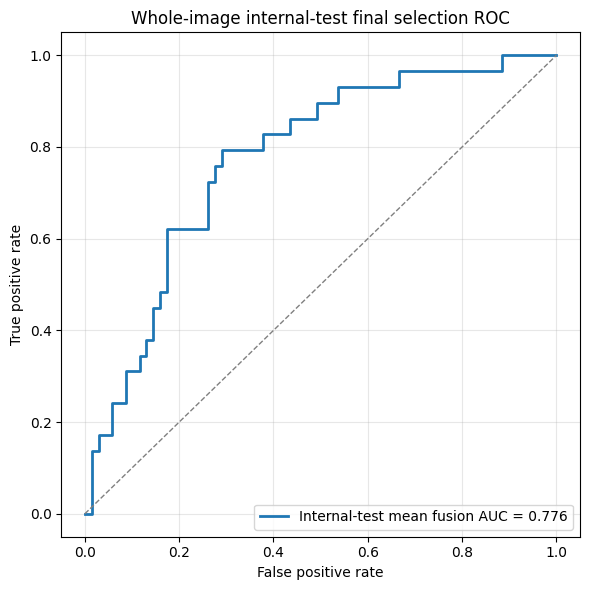

Saved internal-test ROC: /host/d/projects/Habitats/models/Prognosis/whole_image/final_selections/cv_manual_mean_selection/ROC_curve_internal_test_final_selection_mean.pdf


In [28]:
# ============================================================
# 13. Plot and save internal-test mean-fusion ROC
# ============================================================

test_roc_save_path = os.path.join(final_selection_out_dir, "ROC_curve_internal_test_final_selection_mean.pdf")

fpr, tpr, _ = roc_curve(y_test_true, test_merged_df["prob_final_mean"].astype(float).to_numpy())
test_auc_value = safe_auc(y_test_true, test_merged_df["prob_final_mean"].astype(float).to_numpy())

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"Internal-test mean fusion AUC = {test_auc_value:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Whole-image internal-test final selection ROC")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(test_roc_save_path)
plt.show()

print("Saved internal-test ROC:", test_roc_save_path)